# SVR Optuna

In [6]:
import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))


### Memuat dan Split Data Terskalasi

In [7]:
from sklearn.preprocessing import StandardScaler

processed_file = os.path.join("..", "data", "processed", "ihsg_processed_features.csv")
if not os.path.exists(processed_file):
    raise FileNotFoundError(f"File {processed_file} tidak ditemukan. Jalankan Data_Preparation.ipynb dulu!")
    
df = pd.read_csv(processed_file, index_col=0, parse_dates=True)
df = df.sort_index()

feature_cols = ['EMA_9', 'SMA_5', 'SMA_15', 'SMA_30', 'RSI', 'MACD', 'MACD_signal']
target_col = 'Target_Close'

X = df[feature_cols]
y = df[target_col]

total_rows = len(df)
train_end = int(total_rows * 0.70)
val_end = train_end + int(total_rows * 0.15)

X_train_raw, y_train_raw = X.iloc[:train_end], y.iloc[:train_end]
X_val_raw, y_val_raw = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test_raw, y_test_raw = X.iloc[val_end:], y.iloc[val_end:]

scalerX = StandardScaler()
scalery = StandardScaler()

X_train = pd.DataFrame(scalerX.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
X_val = pd.DataFrame(scalerX.transform(X_val_raw), columns=X_val_raw.columns, index=X_val_raw.index)
X_test = pd.DataFrame(scalerX.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)

y_train = pd.Series(scalery.fit_transform(y_train_raw.values.reshape(-1, 1)).flatten(), index=y_train_raw.index)
y_val = pd.Series(scalery.transform(y_val_raw.values.reshape(-1, 1)).flatten(), index=y_val_raw.index)
# Untuk test set, kita simpan y aslinya di variabel y_test agar mudah dievaluasi secara natural
y_test = y_test_raw 

print(f"Data Shapes - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Data Shapes - Train: (2695, 7), Val: (577, 7), Test: (579, 7)


### Training Model SVR dengan Optuna

In [8]:
import joblib
import optuna
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1.0, 2000.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.001, 10.0, log=True),
        'epsilon': trial.suggest_float('epsilon', 0.0001, 0.1, log=True),
        'kernel': 'rbf'
    }
    model = SVR(**params, max_iter=100000)
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    return mean_squared_error(y_val, val_preds)

start_time = time.time()
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)
execution_time = time.time() - start_time

print(f"Waktu Eksekusi: {execution_time:.2f} detik")
print(f"Parameter Terbaik: {study.best_params}")

best_params = study.best_params
best_params['kernel'] = 'rbf'

best_model = SVR(**best_params)
best_model.fit(X_train, y_train)

test_preds = best_model.predict(X_test)
test_preds = scalery.inverse_transform(test_preds.reshape(-1, 1)).flatten()
test_mse = mean_squared_error(y_test, test_preds)
test_rmse = np.sqrt(test_mse)
print(f"Hasil Test Set -> MSE: {test_mse:.4f} | RMSE: {test_rmse:.4f}")


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\ThomPC\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\ThomPC\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\ThomPC\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\ThomPC\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\ThomPC\anaconda

Waktu Eksekusi: 56.09 detik
Parameter Terbaik: {'C': 865.3958910936518, 'gamma': 0.001522779986902099, 'epsilon': 0.008245874864982553}
Hasil Test Set -> MSE: 6042.3347 | RMSE: 77.7325


### Evaluasi & Percentage Error

In [9]:
joblib.dump(scalerX, os.path.join("..", "outputs", "models", "scalerX.pkl"))
joblib.dump(scalery, os.path.join("..", "outputs", "models", "scalery.pkl"))
actual = y_test.values
percentage_errors = np.abs((test_preds - actual) / actual) * 100
mape = np.mean(percentage_errors)
print(f"MAPE (Rata-rata % Error): {mape:.4f}%")

# Simpan Metrik & Model
os.makedirs(os.path.join("..", "outputs", "metrics"), exist_ok=True)
os.makedirs(os.path.join("..", "outputs", "models"), exist_ok=True)

metrics_results = {
    "method": "SVR_Optuna",
    "execution_time_seconds": execution_time,
    "best_params": best_params,
    "best_validation_mse": float(study.best_value),
    "test_mse": float(test_mse),
    "test_rmse": float(test_rmse),
    "mape": float(mape)
}

with open(os.path.join("..", "outputs", "metrics", "optuna_SVR_results.json"), "w") as f:
    json.dump(metrics_results, f, indent=4)

joblib.dump(best_model, os.path.join("..", "outputs", "models", "svr_optuna.pkl"))
print("Model SVR (pkl) dan metrik berhasil disimpan.")


MAPE (Rata-rata % Error): 0.8157%
Model SVR (pkl) dan metrik berhasil disimpan.


### Visualisasi: Actual vs Predicted

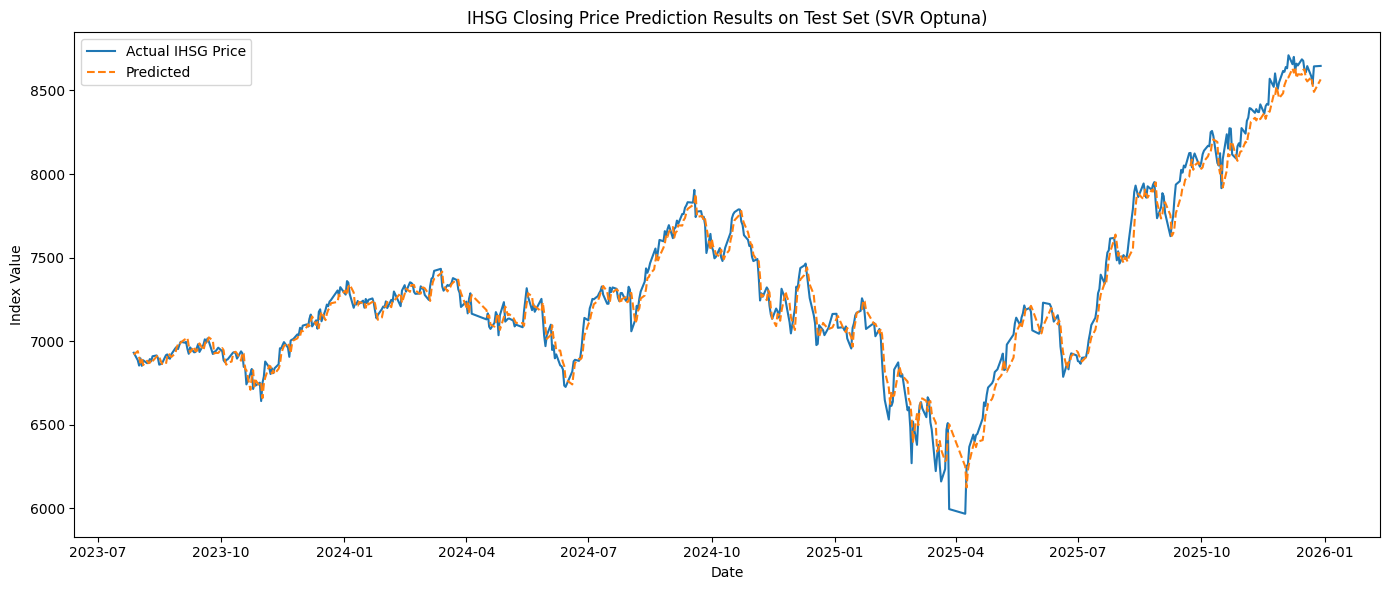

In [10]:
plot_dir = os.path.join("..", "outputs", "plots")
os.makedirs(plot_dir, exist_ok=True)

plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Actual IHSG Price", color='#1f77b4', linewidth=1.5)
plt.plot(y_test.index, test_preds, label="Predicted", color='#ff7f0e', linestyle='--', linewidth=1.5)
plt.title("IHSG Closing Price Prediction Results on Test Set (SVR Optuna)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "actual_vs_predicted_svr_optuna.png"), dpi=300)
plt.show()
